In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA

In [2]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense 

In [3]:
# ================================
# 1. LOAD DATASETS (LOCAL FILES)
# ================================

import pandas as pd

# Dataset 1 — Global Temperature (monthly)
temp = pd.read_csv('/Users/pericles/Downloads/monthly(2).csv')

# Year column is YYYY-MM → use %Y-%m
temp["Date"] = pd.to_datetime(temp["Year"], format="%Y-%m")

# Correct column name in your file = Mean
temp = temp[["Date", "Mean"]].rename(columns={"Mean": "Value"})
temp.set_index("Date", inplace=True)


# Dataset 2 — CO2 (NOAA file with header comments)
co2 = pd.read_csv(
    '/Users/pericles/Downloads/co2_mm_mlo(1).csv',
    comment="#"
)

# Create proper Date from Year + Month
co2["Date"] = pd.to_datetime(
    co2["year"].astype(str) + "-" + co2["month"].astype(str),
    format="%Y-%m"
)

co2 = co2[["Date", "average"]].rename(columns={"average": "Value"})
co2.set_index("Date", inplace=True)
co2 = co2.dropna()

# Dataset 3 — Sea Level (yearly)
sea = pd.read_csv('/Users/pericles/Downloads/global_sea_level.csv')
sea["Date"] = pd.to_datetime(sea["Year"], format="%Y")
sea = sea[["Date", "CSIRO Adjusted Sea Level"]].rename(
    columns={"CSIRO Adjusted Sea Level": "Value"}
)
sea.set_index("Date", inplace=True)


datasets = {
    "Temperature": temp,
    "CO2": co2,
    "SeaLevel": sea
}

print("Datasets loaded successfully")

Datasets loaded successfully


In [4]:
# ================================
# HELPER FUNCTIONS
# ================================

def train_test_split(series, split=0.8):
    n = int(len(series)*split)
    return series[:n], series[n:]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [5]:
# ================================
# MODEL 1 — ARIMA
# ================================

def run_arima(train, test):
    model = ARIMA(train, order=(2,1,2))
    model_fit = model.fit()
    forecast = model_fit.forecast(len(test))
    return forecast


In [6]:
# ================================
# MODEL 2 — LINEAR REGRESSION
# ================================

def run_lr(train, test):
    X_train = np.arange(len(train)).reshape(-1,1)
    y_train = train.values
    
    X_test = np.arange(len(train), len(train)+len(test)).reshape(-1,1)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return pred

In [7]:
# ================================
# MODEL 3 — LSTM
# ================================

def create_sequences(data, seq_len=5):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

def run_lstm(train, test):
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    
    seq_len = 5
    X_train, y_train = create_sequences(train_scaled, seq_len)
    
    model = Sequential([
        LSTM(32, activation="tanh", input_shape=(seq_len,1)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=40, verbose=0)
    
    history = train_scaled[-seq_len:]
    preds = []
    
    for _ in range(len(test)):
        x = history.reshape(1,seq_len,1)
        yhat = model.predict(x, verbose=0)
        preds.append(yhat[0,0])
        history = np.append(history[1:], yhat)
    
    preds = scaler.inverse_transform(np.array(preds).reshape(-1,1))
    return preds.flatten()


/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameter

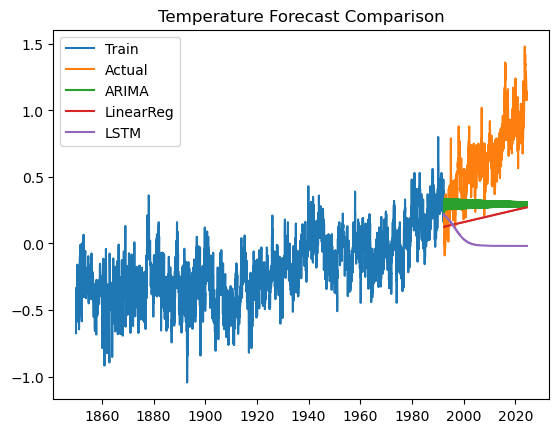

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


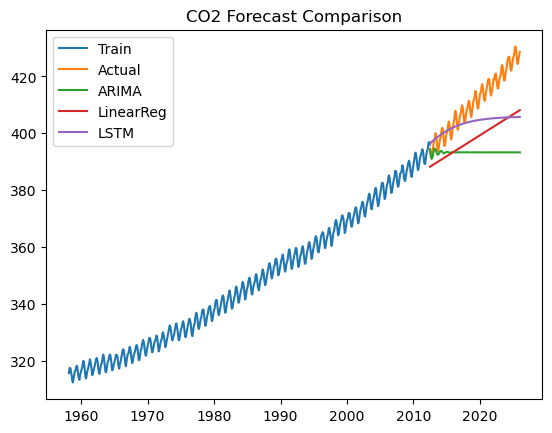

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


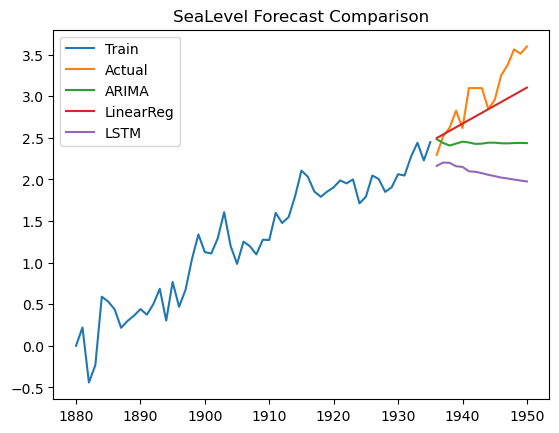


MODEL COMPARISON:
       Dataset  ARIMA_RMSE    LR_RMSE  LSTM_RMSE
0  Temperature    0.421120   0.485389   0.680954
1          CO2   20.387009  13.637697  11.030269
2     SeaLevel    0.699697   0.311102   1.041208


In [8]:
# ================================
# RUN EXPERIMENTS
# ================================

results = []

for name, df in datasets.items():
    series = df["Value"].dropna()
    train, test = train_test_split(series)
    
    arima_pred = run_arima(train, test)
    lr_pred = run_lr(train, test)
    lstm_pred = run_lstm(train, test)
    
    r1 = rmse(test, arima_pred)
    r2 = rmse(test, lr_pred)
    r3 = rmse(test, lstm_pred)
    
    results.append([name, r1, r2, r3])
    
    # Plot
    plt.figure()
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Actual")
    plt.plot(test.index, arima_pred, label="ARIMA")
    plt.plot(test.index, lr_pred, label="LinearReg")
    plt.plot(test.index, lstm_pred, label="LSTM")
    plt.title(f"{name} Forecast Comparison")
    plt.legend()
    plt.show()

# ================================
# RESULTS TABLE
# ================================

results_df = pd.DataFrame(
    results,
    columns=["Dataset","ARIMA_RMSE","LR_RMSE","LSTM_RMSE"]
)

print("\nMODEL COMPARISON:")
print(results_df)


BEST MODEL FOR EACH DATASET:
       Dataset  Best_Model
0  Temperature  ARIMA_RMSE
1          CO2   LSTM_RMSE
2     SeaLevel     LR_RMSE


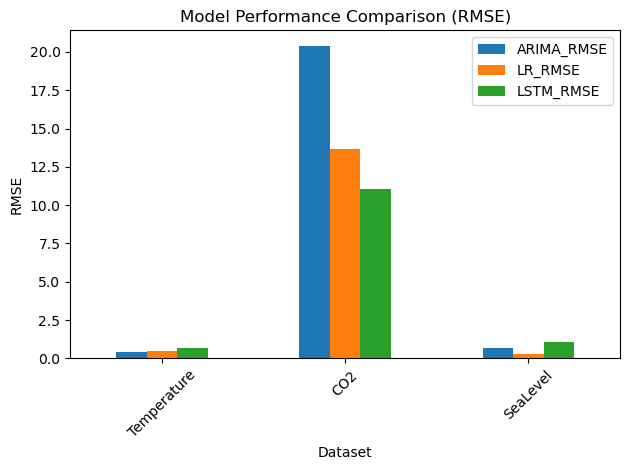


Results saved to model_comparison_results.csv

AVERAGE RMSE OF MODELS:
ARIMA_RMSE    7.169275
LR_RMSE       4.811396
LSTM_RMSE     4.250810
dtype: float64

Overall Best Performing Model: LSTM_RMSE


In [9]:
# ================================
# FIND BEST MODEL FOR EACH DATASET
# ================================

results_df["Best_Model"] = results_df[
    ["ARIMA_RMSE", "LR_RMSE", "LSTM_RMSE"]
].idxmin(axis=1)

print("\nBEST MODEL FOR EACH DATASET:")
print(results_df[["Dataset","Best_Model"]])


# ================================
# BAR CHART COMPARISON
# ================================

results_df.set_index("Dataset")[["ARIMA_RMSE","LR_RMSE","LSTM_RMSE"]].plot(
    kind="bar"
)

plt.title("Model Performance Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ================================
# SAVE RESULTS
# ================================

results_df.to_csv("model_comparison_results.csv", index=False)

print("\nResults saved to model_comparison_results.csv")


# ================================
# OVERALL BEST MODEL
# ================================

avg_scores = results_df[["ARIMA_RMSE","LR_RMSE","LSTM_RMSE"]].mean()

print("\nAVERAGE RMSE OF MODELS:")
print(avg_scores)

best_overall = avg_scores.idxmin()

print("\nOverall Best Performing Model:", best_overall)

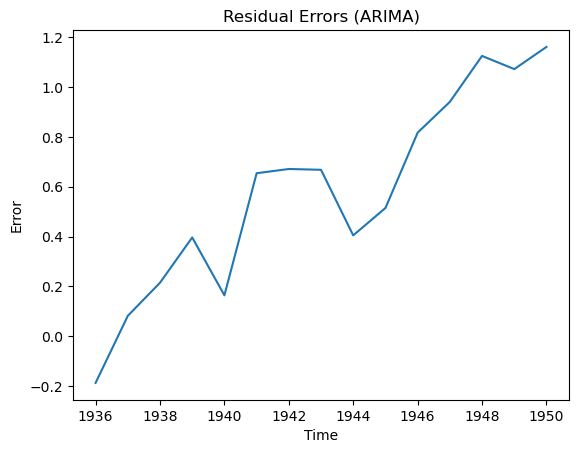

In [14]:
# RESIDUAL ANALYSIS

arima_residuals = y_test - arima_pred

plt.figure()

plt.plot(arima_residuals)

plt.title("Residual Errors (ARIMA)")
plt.xlabel("Time")
plt.ylabel("Error")

plt.show()